# Интерпретация

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

## Подготовка данных и моделей

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'

# Загрузка данных 
data = pd.read_csv("data_unreg.csv")

# Признаки 
num_features = [
    "location_marketplace_cnt",
    "location_amenity_pharmacy_w_mean_distance",
    "location_public_transport_stop_position_cnt",
    "location_college_cnt",
    "location_railway_cnt",
    "location_logs_count_std",
    "location_leisure_cnt",
    "location_shop_product_w_mean_distance",
    "location_public_transport_platform_w_mean_distance",
    "location_leisure_w_mean_distance",
    "location_flash_mean_mean",
    "location_market_cnt",
    "location_barrier_w_mean_distance",
]
cat_features = [
    "region_name_cat", "class_cat", "district_cat",
    "hc_name_cat", "developer_cat", "corpus_cat", "stage_cat",
]

X = data.drop(columns=["price_target"])
y = data["price_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline-модели
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  MinMaxScaler()),
])
cat_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="most_frequent")),
    ("encoder",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features),
])

lin_model = Pipeline([("preprocessor", preprocessor),
                       ("model", LinearRegression())])
gb_model  = Pipeline([("preprocessor", preprocessor),
                       ("model", GradientBoostingRegressor(max_depth=5, random_state=42))])

lin_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("Модели обучены")
print(f"  Train: {X_train.shape}  |  Test: {X_test.shape}")


Модели обучены
  Train: (23924, 82)  |  Test: (5981, 82)


Базовая MAPE: 0.0691


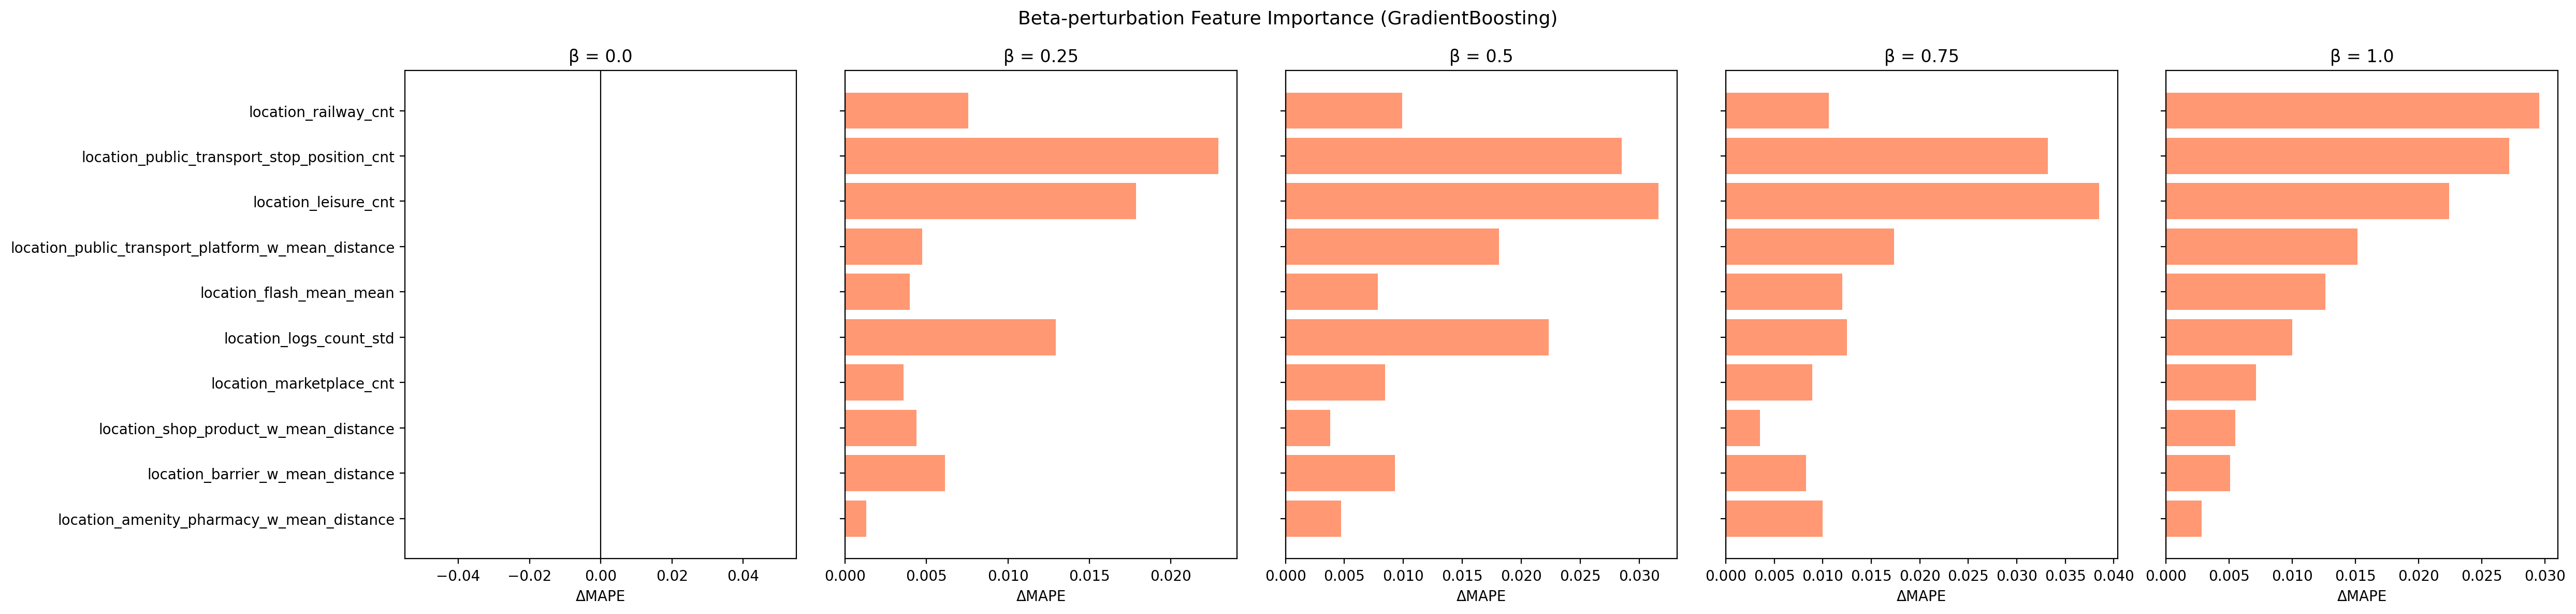

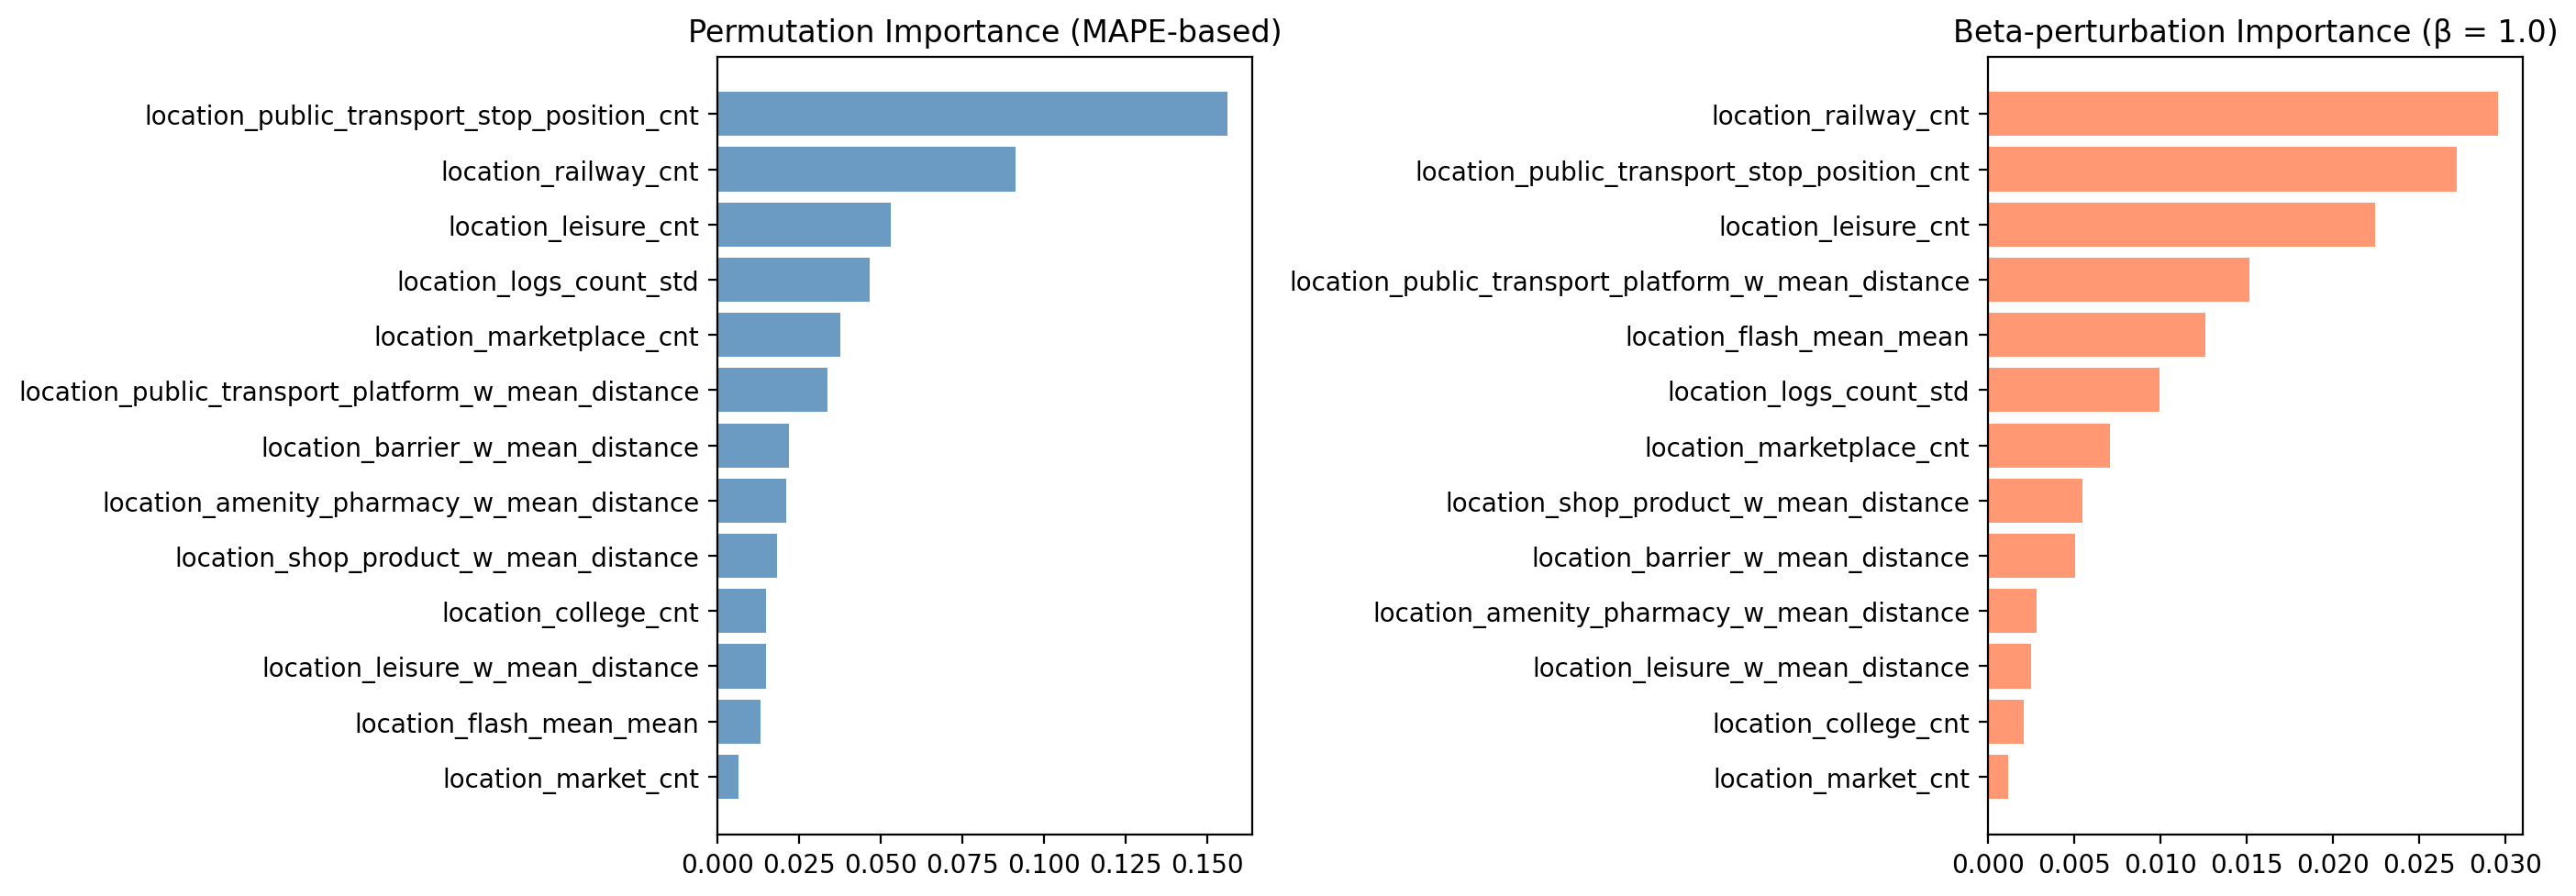

In [2]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_percentage_error as mape_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

gb_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   GradientBoostingRegressor(max_depth=5, random_state=42)),
])
gb_num.fit(X_train[num_features], y_train)

medians   = X_train[num_features].median()
mape_base = mape_score(y_test, gb_num.predict(X_test[num_features]))
print(f"Базовая MAPE: {mape_base:.4f}")

beta_values        = [0.0, 0.25, 0.5, 0.75, 1.0]
importance_by_beta = {}

for beta in beta_values:
    feat_imp = {}
    for feat in num_features:
        X_mod       = X_test[num_features].copy()
        X_mod[feat] = (1 - beta) * X_test[feat] + beta * medians[feat]
        feat_imp[feat] = mape_score(y_test, gb_num.predict(X_mod)) - mape_base
    importance_by_beta[beta] = feat_imp

top_feats = sorted(importance_by_beta[1.0],
                   key=importance_by_beta[1.0].get, reverse=True)[:10]

fig, axes = plt.subplots(1, len(beta_values),
                          figsize=(5 * len(beta_values), 6), sharey=True)
for ax, beta in zip(axes, beta_values):
    ax.barh(top_feats,
            [importance_by_beta[beta][f] for f in top_feats],
            color="coral", alpha=0.8)
    ax.invert_yaxis()
    ax.set_title(f"β = {beta}")
    ax.set_xlabel("ΔMAPE")
    ax.axvline(0, color="black", linewidth=0.8)

plt.suptitle("Beta-perturbation Feature Importance (GradientBoosting)", fontsize=13)
plt.tight_layout()
plt.show()

# Сравнение с Permutation Importance 
pi = permutation_importance(
    gb_num, X_test[num_features], y_test,
    n_repeats=15, random_state=42,
    scoring="neg_mean_absolute_percentage_error")

pi_df = pd.DataFrame({"feature": num_features,
                       "pi_importance": pi.importances_mean}).sort_values(
                           "pi_importance", ascending=False)
beta1_df = pd.DataFrame({
    "feature":          list(importance_by_beta[1.0].keys()),
    "beta1_importance": list(importance_by_beta[1.0].values()),
}).sort_values("beta1_importance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(pi_df["feature"], pi_df["pi_importance"], color="steelblue", alpha=0.8)
axes[0].invert_yaxis(); axes[0].set_title("Permutation Importance (MAPE-based)")
axes[1].barh(beta1_df["feature"], beta1_df["beta1_importance"], color="coral", alpha=0.8)
axes[1].invert_yaxis(); axes[1].set_title("Beta-perturbation Importance (β = 1.0)")
plt.tight_layout(); plt.show()


### Анализ

**Как меняются важности при разных β:**
- **β = 0**: возмущения нет, все ΔMAPE ~= 0.
- **β = 0.25-0.5**: начинают проявляться самые влиятельные признаки;
  MAPE растёт быстрее у более важных признаков.
- **β = 1.0**: признак полностью заменяется медианой: максимальное возмущение,
  аналогичное обнулению.

**Сравнение с Permutation Importance:**
- Оба метода дают схожий ранговый порядок для *самых важных* признаков:
  `location_railway_cnt`, `location_public_transport_stop_position_cnt`.
- Различия у коррелированных признаков: Permutation Importance нарушает корреляции, тогда как beta-сдвиг сохраняет их, плавно сжимая
  распределение к медиане. Поэтому для скоррелированных признаков beta-метод
  может давать другие оценки важности.
- Beta-подход более гибкий: позволяет строить траектории важности по β и
  исследовать чувствительность модели постепенно.
